# Inference: Five Methods, One Loss Function

All five inference methods in diffsed operate on the **same
standardised information Hamiltonian**:

$$H(\boldsymbol{\xi} \mid \mathbf{d}) = \tfrac{1}{2}\chi^2 + \tfrac{1}{2}\boldsymbol{\xi}^\top\boldsymbol{\xi}$$

They differ only in **how they explore the posterior landscape**.
This tutorial demonstrates each method on the same mock galaxy,
compares their posteriors, and provides practical guidance on when
to use which.

| Method | Type | Exact? | D range | Speed |
|--------|------|--------|---------|-------|
| **MAP** (Adam) | Optimisation | Point estimate | Any | ~1 s |
| **Ray Tracing** | MCMC | Yes | ≲300 | ~min |
| **NUTS** | MCMC (HMC) | Yes | ≲20 | ~min |
| **geoVI** | Variational | Approximate | ≲10⁴ | ~min |
| **MGVI** | Variational | Approximate | ≲10⁵ | ~s–min |

**By the end you will know:**
1. How each method works (conceptually)
2. When each method is appropriate
3. How to diagnose convergence
4. Where the variational approximations break down

In [1]:
import time, os
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import numpy as np

from diffsed import (
    Model, ParamSpec, Uniform, Fixed, Fitter,
    load_ssp_data, load_filter_set,
)
import sys; sys.path.insert(0, ".")
import sys; sys.path.insert(0, "..")
from _plot_style import (setup_style, COLORS, SAMPLER_STYLE, SDSS_WAVE_EFF,
                          plot_sfh, plot_sfh_comparison,
                          plot_corner_comparison, convergence_table)
setup_style()

FIG_DIR = "../notebook_figures"
os.makedirs(FIG_DIR, exist_ok=True)
def savefig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, f"T03_{name}.png"),
                bbox_inches="tight", dpi=72)

ssp_data = load_ssp_data(
    "../../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])

## Setup: Stochastic Mock Galaxy

We use the full stochastic model ($D \approx 137$) so that Ray Tracing
and geoVI are necessary — NUTS would struggle at this dimensionality.
We also fit the same galaxy with the parametric model ($D = 7$) to
demonstrate NUTS.

In [2]:
# ── Stochastic model ─────────────────────────────────────────────
spec_s = ParamSpec(
    sfh_alpha=Uniform(0.5, 3.0), sfh_beta=Uniform(0.5, 3.0),
    sfh_tau_peak_gyr=Uniform(0.5, 13.0), sfh_peak_sfr=Uniform(0.1, 100.0),
    psd_sigma=Uniform(0.1, 4.0), psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0), dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=Fixed(-0.7), redshift=Fixed(0.1),
    stochastic=True, n_grid=128,
)
model_s = Model(spec_s, ssp_data, filters=filters)

key = jax.random.PRNGKey(42)
true_s = spec_s.sample(key)
true_s.update(sfh_alpha=1.0, sfh_beta=1.5, sfh_tau_peak_gyr=8.0,
              sfh_peak_sfr=40.0, psd_sigma=2.0, psd_tau_myr=20.0,
              met_logzsol=-0.3, dust_tau_bc=0.5, dust_tau_diff=0.3)
mock_s = model_s.mock(true_s, snr=20.0, key=key)
print(f"Stochastic model: D = {spec_s.n_free}")

# ── Parametric model (for NUTS comparison) ────────────────────────
spec_p = ParamSpec(
    sfh_alpha=Uniform(0.5, 3.0), sfh_beta=Uniform(0.5, 3.0),
    sfh_tau_peak_gyr=Uniform(0.5, 13.0), sfh_peak_sfr=Uniform(0.1, 100.0),
    psd_sigma=Fixed(0.0), psd_tau_myr=Fixed(50.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0), dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=Fixed(-0.7), redshift=Fixed(0.1), stochastic=False,
)
model_p = Model(spec_p, ssp_data, filters=filters)
true_p = dict(sfh_alpha=1.0, sfh_beta=1.5, sfh_tau_peak_gyr=8.0,
              sfh_peak_sfr=40.0, met_logzsol=-0.3,
              dust_tau_bc=0.5, dust_tau_diff=0.3)
mock_p = model_p.mock(true_p, snr=20.0, key=key)
print(f"Parametric model: D = {spec_p.n_free}")

W0316 02:58:30.782885 5987442 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Stochastic model: D = 9


Parametric model: D = 7


## 1. MAP Optimisation

**MAP** minimises the information Hamiltonian via Adam (Kingma & Ba
2015).  It provides a fast point estimate and initialises the samplers.
MAP is not a posterior — it gives no uncertainty — but it is the
starting point for everything else.

In [3]:
fitter_s = Fitter(model_s, mock_s.flux_obs, mock_s.noise, data_type="photometry")
fitter_p = Fitter(model_p, mock_p.flux_obs, mock_p.noise, data_type="photometry")

t0 = time.perf_counter()
map_s = fitter_s.run("map", n_steps=1000)
print(f"MAP (stochastic): {time.perf_counter()-t0:.1f} s")

t0 = time.perf_counter()
map_p = fitter_p.run("map", n_steps=500)
print(f"MAP (parametric): {time.perf_counter()-t0:.1f} s")

  Step     0/1000: loss = 31.5795
  Step   200/1000: loss = 2.6616
  Step   400/1000: loss = 2.4350
  Step   600/1000: loss = 2.2695
  Step   800/1000: loss = 1.9848
  Step   999/1000: loss = 1.7284
  MAP (ADAM) complete in 0.3s, 1000 steps
MAP (stochastic): 0.5 s


  Step     0/500: loss = 68.1967
  Step   200/500: loss = 2.2697
  Step   400/500: loss = 2.1923
  Step   499/500: loss = 2.1558
  MAP (ADAM) complete in 0.2s, 500 steps
MAP (parametric): 0.2 s


## 2. Ray Tracing Sampler (Behroozi 2025)

The **Ray Tracing Sampler** propagates proposals along straight-line
trajectories that refract at iso-probability surfaces via Snell's law.
Key advantages:

- **~250× more gradient-noise tolerant** than HMC (Behroozi 2025)
- **Crosses likelihood barriers** that trap HMC walkers
- **Exact** — produces unbiased posterior samples

It is the recommended method for the stochastic model ($D \sim 137$).

In [4]:
t0 = time.perf_counter()
rt_s = fitter_s.run("raytrace", init_from=map_s,
                    n_burnin=200, n_steps=2000,
                    step_size=0.005, n_leapfrog_steps=200)
t_rt = time.perf_counter() - t0
accept = rt_s.diagnostics.get("accept_rate_post_burnin", 0)
print(f"Ray Tracing: {t_rt:.1f} s  (acceptance: {accept:.0%})")

Ray Tracing: 137 params, 200 burn-in + 2000 samples, 200 leapfrog/step, step_size=0.0050


  Ray Tracing complete in 0.4s. Acceptance: 99.2% (overall), 99.1% (post burn-in). Samples: 2000
Ray Tracing: 9.6 s  (acceptance: 99%)


## 3. NUTS (Hoffman & Gelman 2014)

The **No-U-Turn Sampler** is the gold standard for low-dimensional
problems.  It automatically tunes trajectory length via the U-turn
criterion.  For $D \lesssim 20$, it gives exact posteriors with
well-calibrated uncertainty.

For $D \sim 137$, NUTS becomes impractical — the U-turn criterion
breaks down and tuning is unreliable.

In [5]:
t0 = time.perf_counter()
nuts_p = fitter_p.run("nuts", init_from=map_p,
                      n_warmup=1000, n_samples=1000)
t_nuts = time.perf_counter() - t0
n_div = nuts_p.diagnostics.get("n_divergent", 0)
print(f"NUTS (parametric): {t_nuts:.1f} s  ({n_div} divergences)")

NUTS: 7 parameters, 1000 warmup, 1000 samples, target_accept=0.8


  Warmup complete (1.2s). Step size: 0.0211


  Sample 200/1000


  Sample 400/1000


  Sample 600/1000


  Sample 800/1000


  Sample 1000/1000


  NUTS complete in 27.8s. Divergences: 6/1000
NUTS (parametric): 28.9 s  (6 divergences)


## 4. geoVI (Frank et al. 2021)

**Geometric Variational Inference** constructs a coordinate
transformation that flattens the posterior metric, then fits a
Gaussian in the flattened coordinates.  It is **approximate** but
scales to $D > 10^4$.  Convergence typically requires ~25 KL
iterations.

geoVI cannot capture genuinely multimodal posteriors.  Where it
disagrees with Ray Tracing, prefer the MCMC result.

In [6]:
t0 = time.perf_counter()
geovi_s = fitter_s.run("geovi", init_from=map_s,
                       n_iterations=25, n_samples=6)
t_geovi = time.perf_counter() - t0
print(f"geoVI (stochastic): {t_geovi:.1f} s")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)
OPTIMIZE_KL: Starting 0001


geoVI: 137 params, 5 data points, 25 iterations


SL: Iteration 0 ⛰:+1.4707e+04 Δ⛰:inf |∇|:1.3740e+04 ➽:5.4484e-04


...

MCG: Iteration 10 ⛰:-4.5485e-06 Δ⛰:2.4506e-09 ➽:1.2315e-07 |∇|:9.8775e-03 ➽:1.3834e-02


M: →:0.5 ↺:True #∇²:94 |↘|:1.488663e-04 🞋:1.370000e-03
M: Iteration 14 ⛰:+6.901809e+01 Δ⛰:7.519250e-08


OPTIMIZE_KL: Iteration 0025 ⛰:+6.9018e+01
OPTIMIZE_KL: #(Nonlinear sampling steps) (4, 9, 5, 3, 4, 4, 3, 4, 4, 3, 4, 4)
OPTIMIZE_KL: #(KL minimization steps) 14
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.2±    0.34, avg:    +0.02±    0.17, #dof:      5'

OPTIMIZE_KL: Prior residual(s):
dust_tau_bc             :: 'reduced χ²:     0.3±    0.24, avg:  +0.0035±    0.55, #dof:      1'
dust_tau_diff           :: 'reduced χ²:    0.49±    0.61, avg:    -0.47±    0.51, #dof:      1'
met_logzsol             :: 'reduced χ²:    0.63±     0.7, avg:    -0.13±    0.78, #dof:      1'
psd_sigma               :: 'reduced χ²:     1.1±     1.8, avg:    +0.17±     1.0, #dof:      1'
psd_tau_myr             :: 'reduced χ²:    0.88±     0.9, avg:     +0.3±    0.89, #dof:      1'
psd_xi                  :: 'reduced χ²:    0.98±    0.12, avg:   -0.023±   0.067, #dof:    128'
sfh_alpha               :: 'reduced χ²:     1.2±     1.9, avg:   -0.034±     1.1, #dof:      1'
sfh_beta                :: '

  Drawing 100 posterior samples...


  geoVI complete in 106.1s, 112 posterior samples
geoVI (stochastic): 106.6 s


## 5. Convergence Diagnostics

In [7]:
convergence_table({
    "RT (D=137)": rt_s,
    "geoVI (D=137)": geovi_s,
    "NUTS (D=7)": nuts_p,
})

Method           ESS min  ESS med   Accept   Diverg     Status
--------------------------------------------------------------
RT (D=137)             5       18      99%        —       WARN
geoVI (D=137)         81      112        —        —       WARN
NUTS (D=7)           335     1000        —        6       WARN

Warnings:
  [RT (D=137)] Low ESS: 8/11 params below 100 (min ESS = 5 for dust_tau_bc)
  [RT (D=137)] Median ESS = 18 < 400 target — consider more samples
  [RT (D=137)] RT acceptance 99% too high — chain barely moving, increase step_size
  [geoVI (D=137)] Low ESS: 1/11 params below 100 (min ESS = 81 for sfh_beta)
  [geoVI (D=137)] Median ESS = 112 < 400 target — consider more samples
  [NUTS (D=7)] WARNING: 6/1000 divergent transitions (0.6%) — posterior may be unreliable


{'RT (D=137)': {'ess_min': np.float64(4.961666211737833),
  'ess_median': 18.043939396037352,
  'n_params_low_ess': 8,
  'acceptance_rate': 0.9913586870949359,
  'converged': False,
  'warnings': ['Low ESS: 8/11 params below 100 (min ESS = 5 for dust_tau_bc)',
   'Median ESS = 18 < 400 target — consider more samples',
   'RT acceptance 99% too high — chain barely moving, increase step_size']},
 'geoVI (D=137)': {'ess_min': np.float64(80.95490318286241),
  'ess_median': 112.0,
  'n_params_low_ess': 1,
  'converged': False,
  'warnings': ['Low ESS: 1/11 params below 100 (min ESS = 81 for sfh_beta)',
   'Median ESS = 112 < 400 target — consider more samples']},
 'NUTS (D=7)': {'ess_min': np.float64(335.35826488257413),
  'ess_median': 1000.0,
  'n_params_low_ess': 0,
  'n_divergent': 6,
  'divergence_pct': 0.6,
  'converged': False,
  'warnings': ['WARNING: 6/1000 divergent transitions (0.6%) — posterior may be unreliable']}}

## 6. Sampler Comparison

### SFH recovery: Ray Tracing vs. geoVI

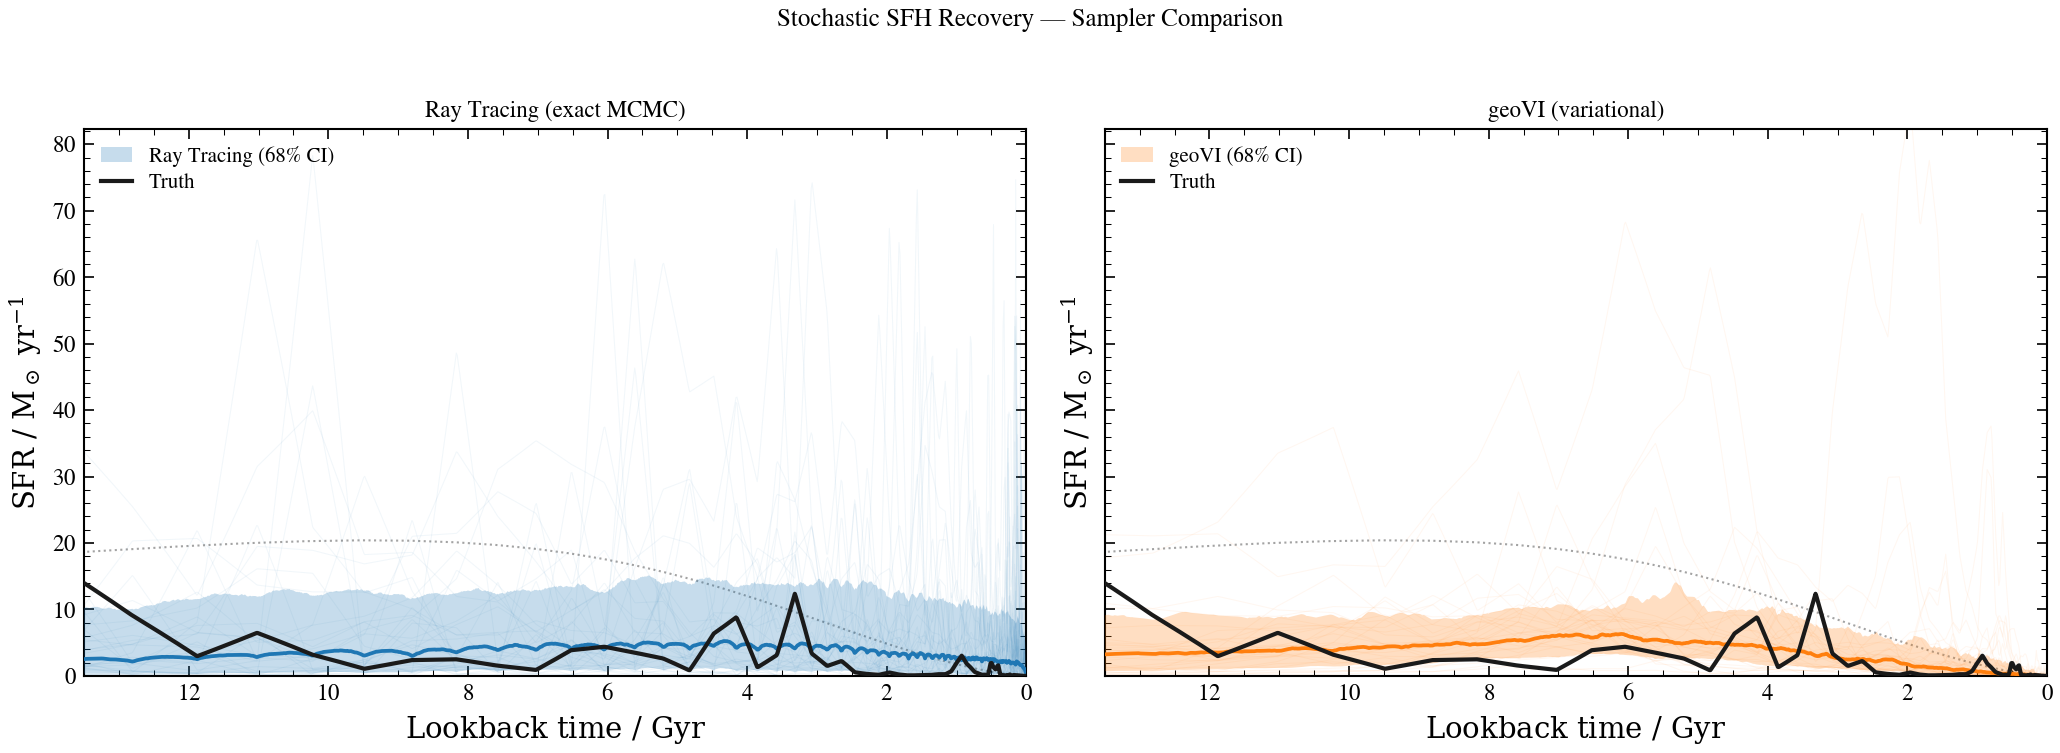

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax = axes[0]
plot_sfh(model_s, rt_s, true_params=true_s, ax=ax, method="RT",
         label="Ray Tracing")
ax.set_title("Ray Tracing (exact MCMC)", fontsize=11)

ax = axes[1]
plot_sfh(model_s, geovi_s, true_params=true_s, ax=ax, method="geoVI",
         label="geoVI")
ax.set_title("geoVI (variational)", fontsize=11)

fig.suptitle("Stochastic SFH Recovery — Sampler Comparison", fontsize=12,
             y=1.02)
fig.tight_layout(); savefig(fig, "sfh_comparison_rt_geovi"); plt.show()

### Corner plot: physical parameters

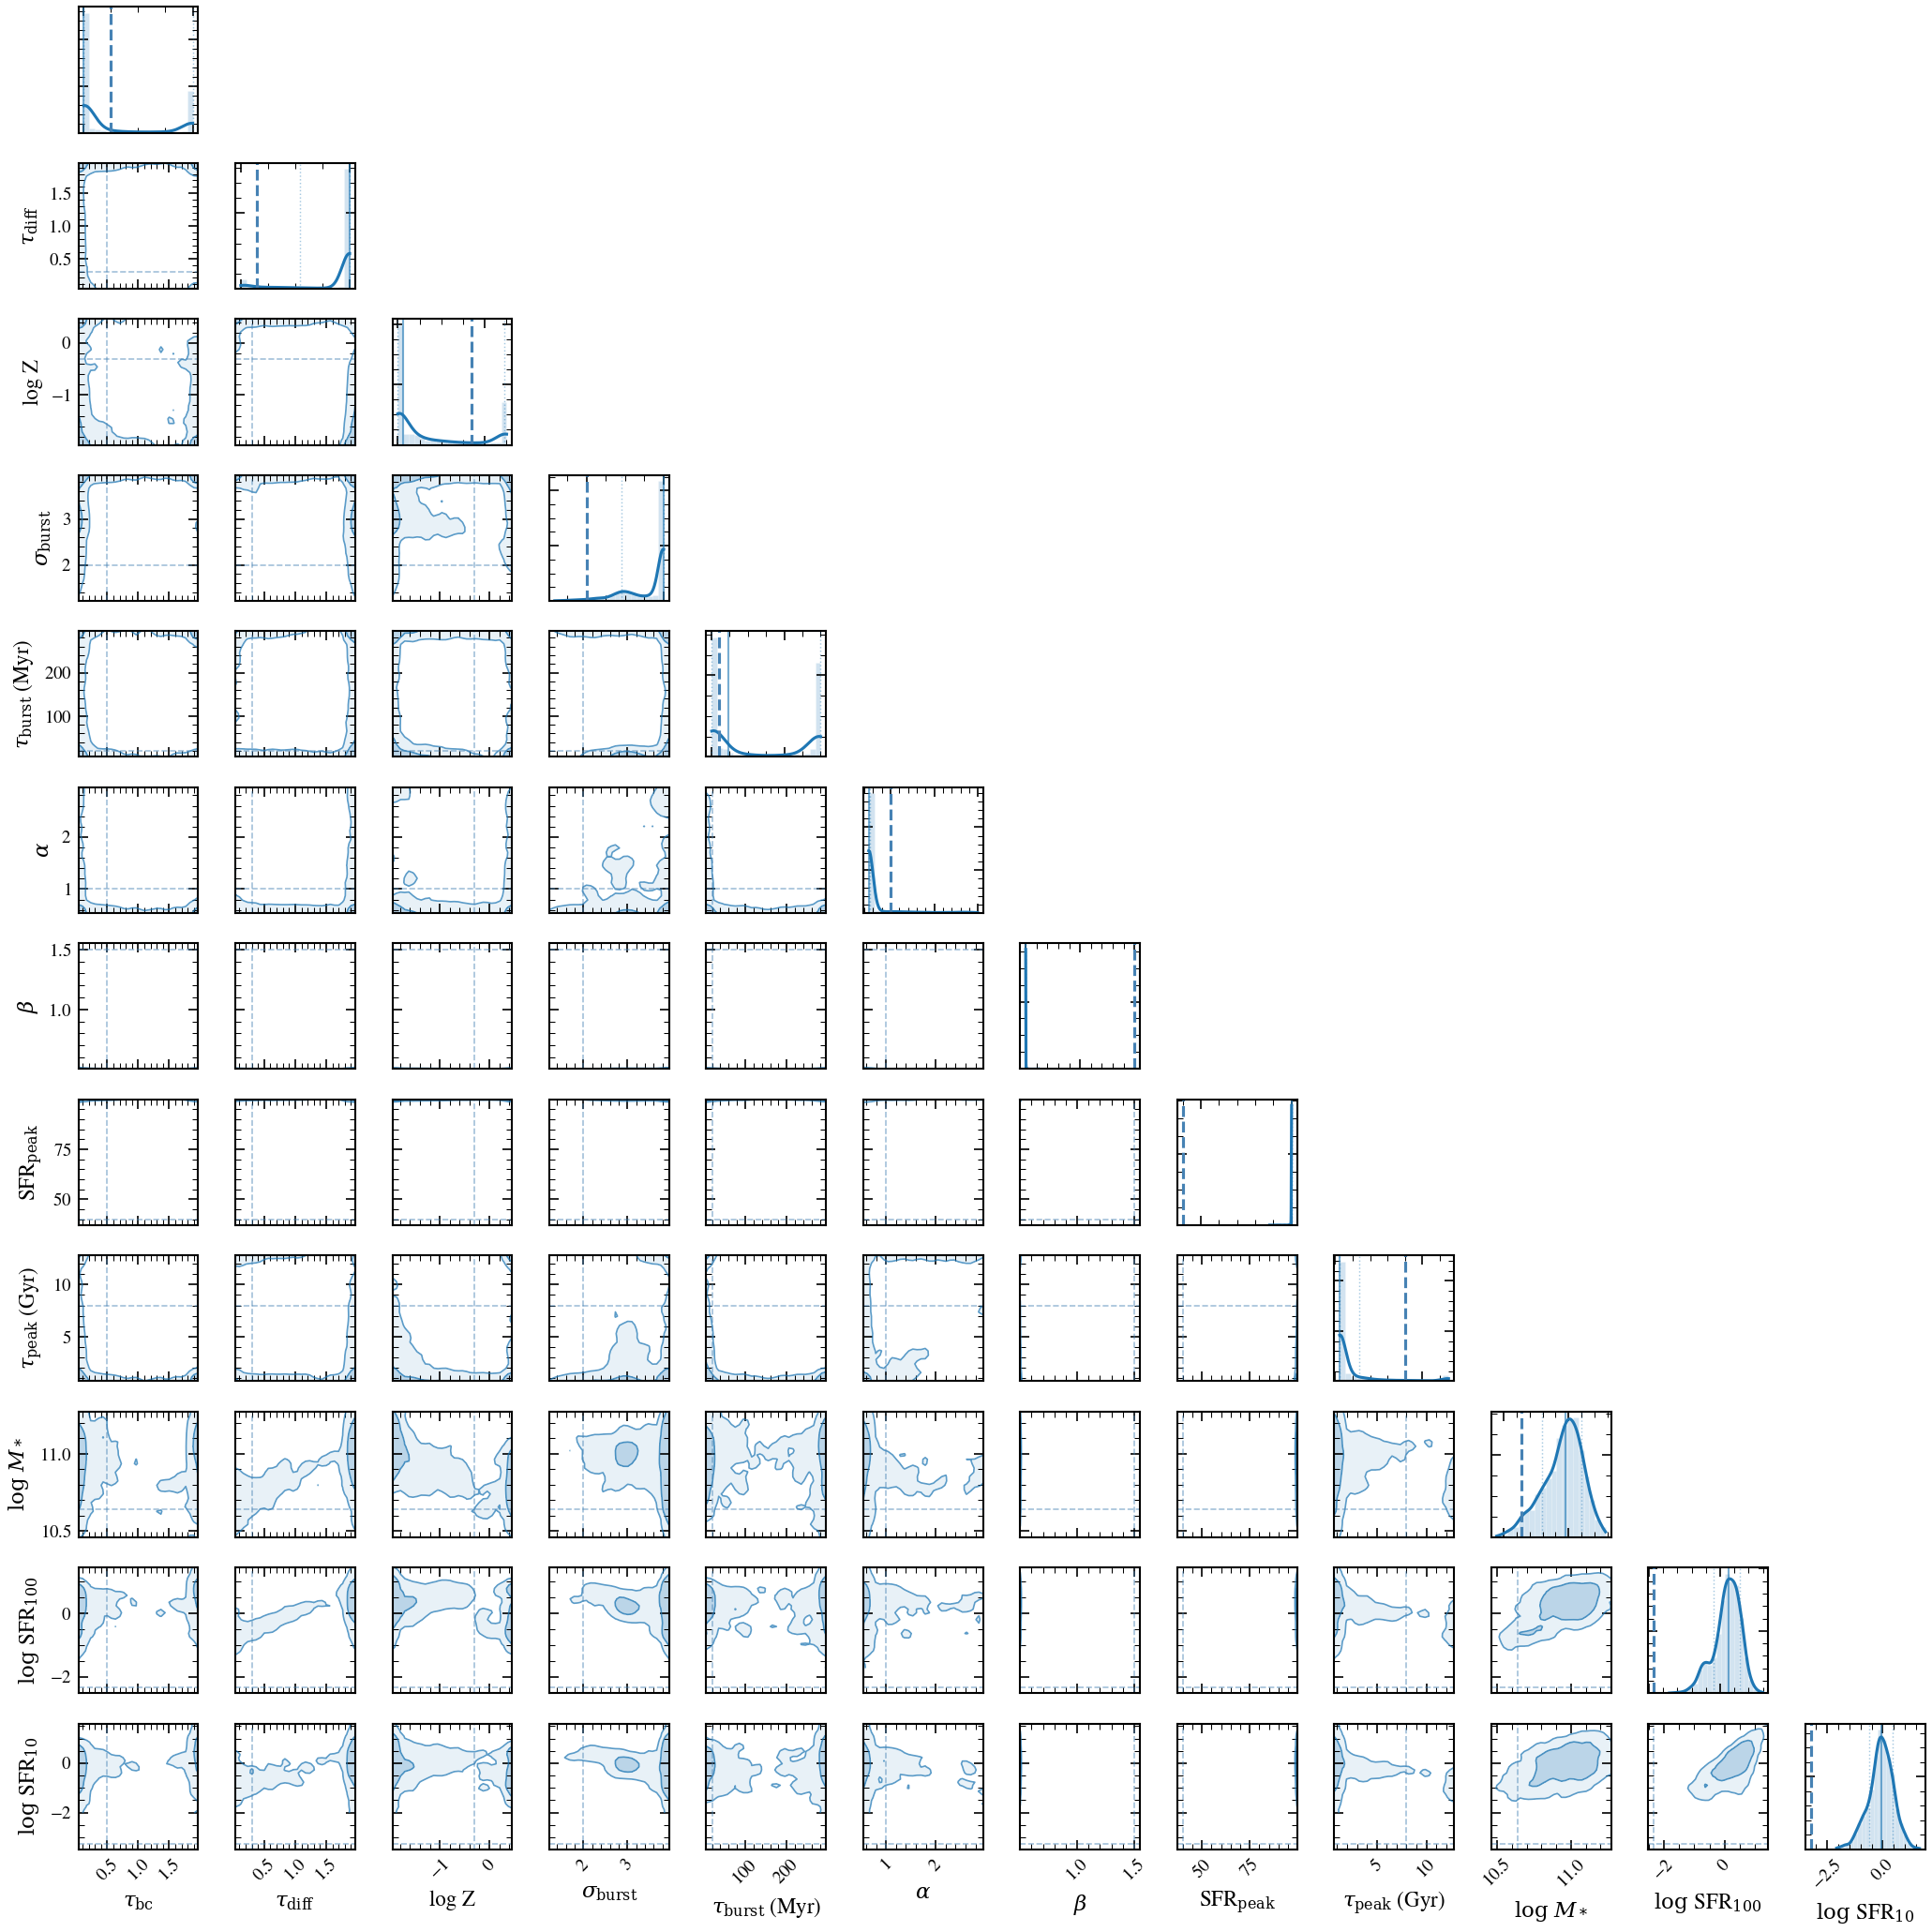

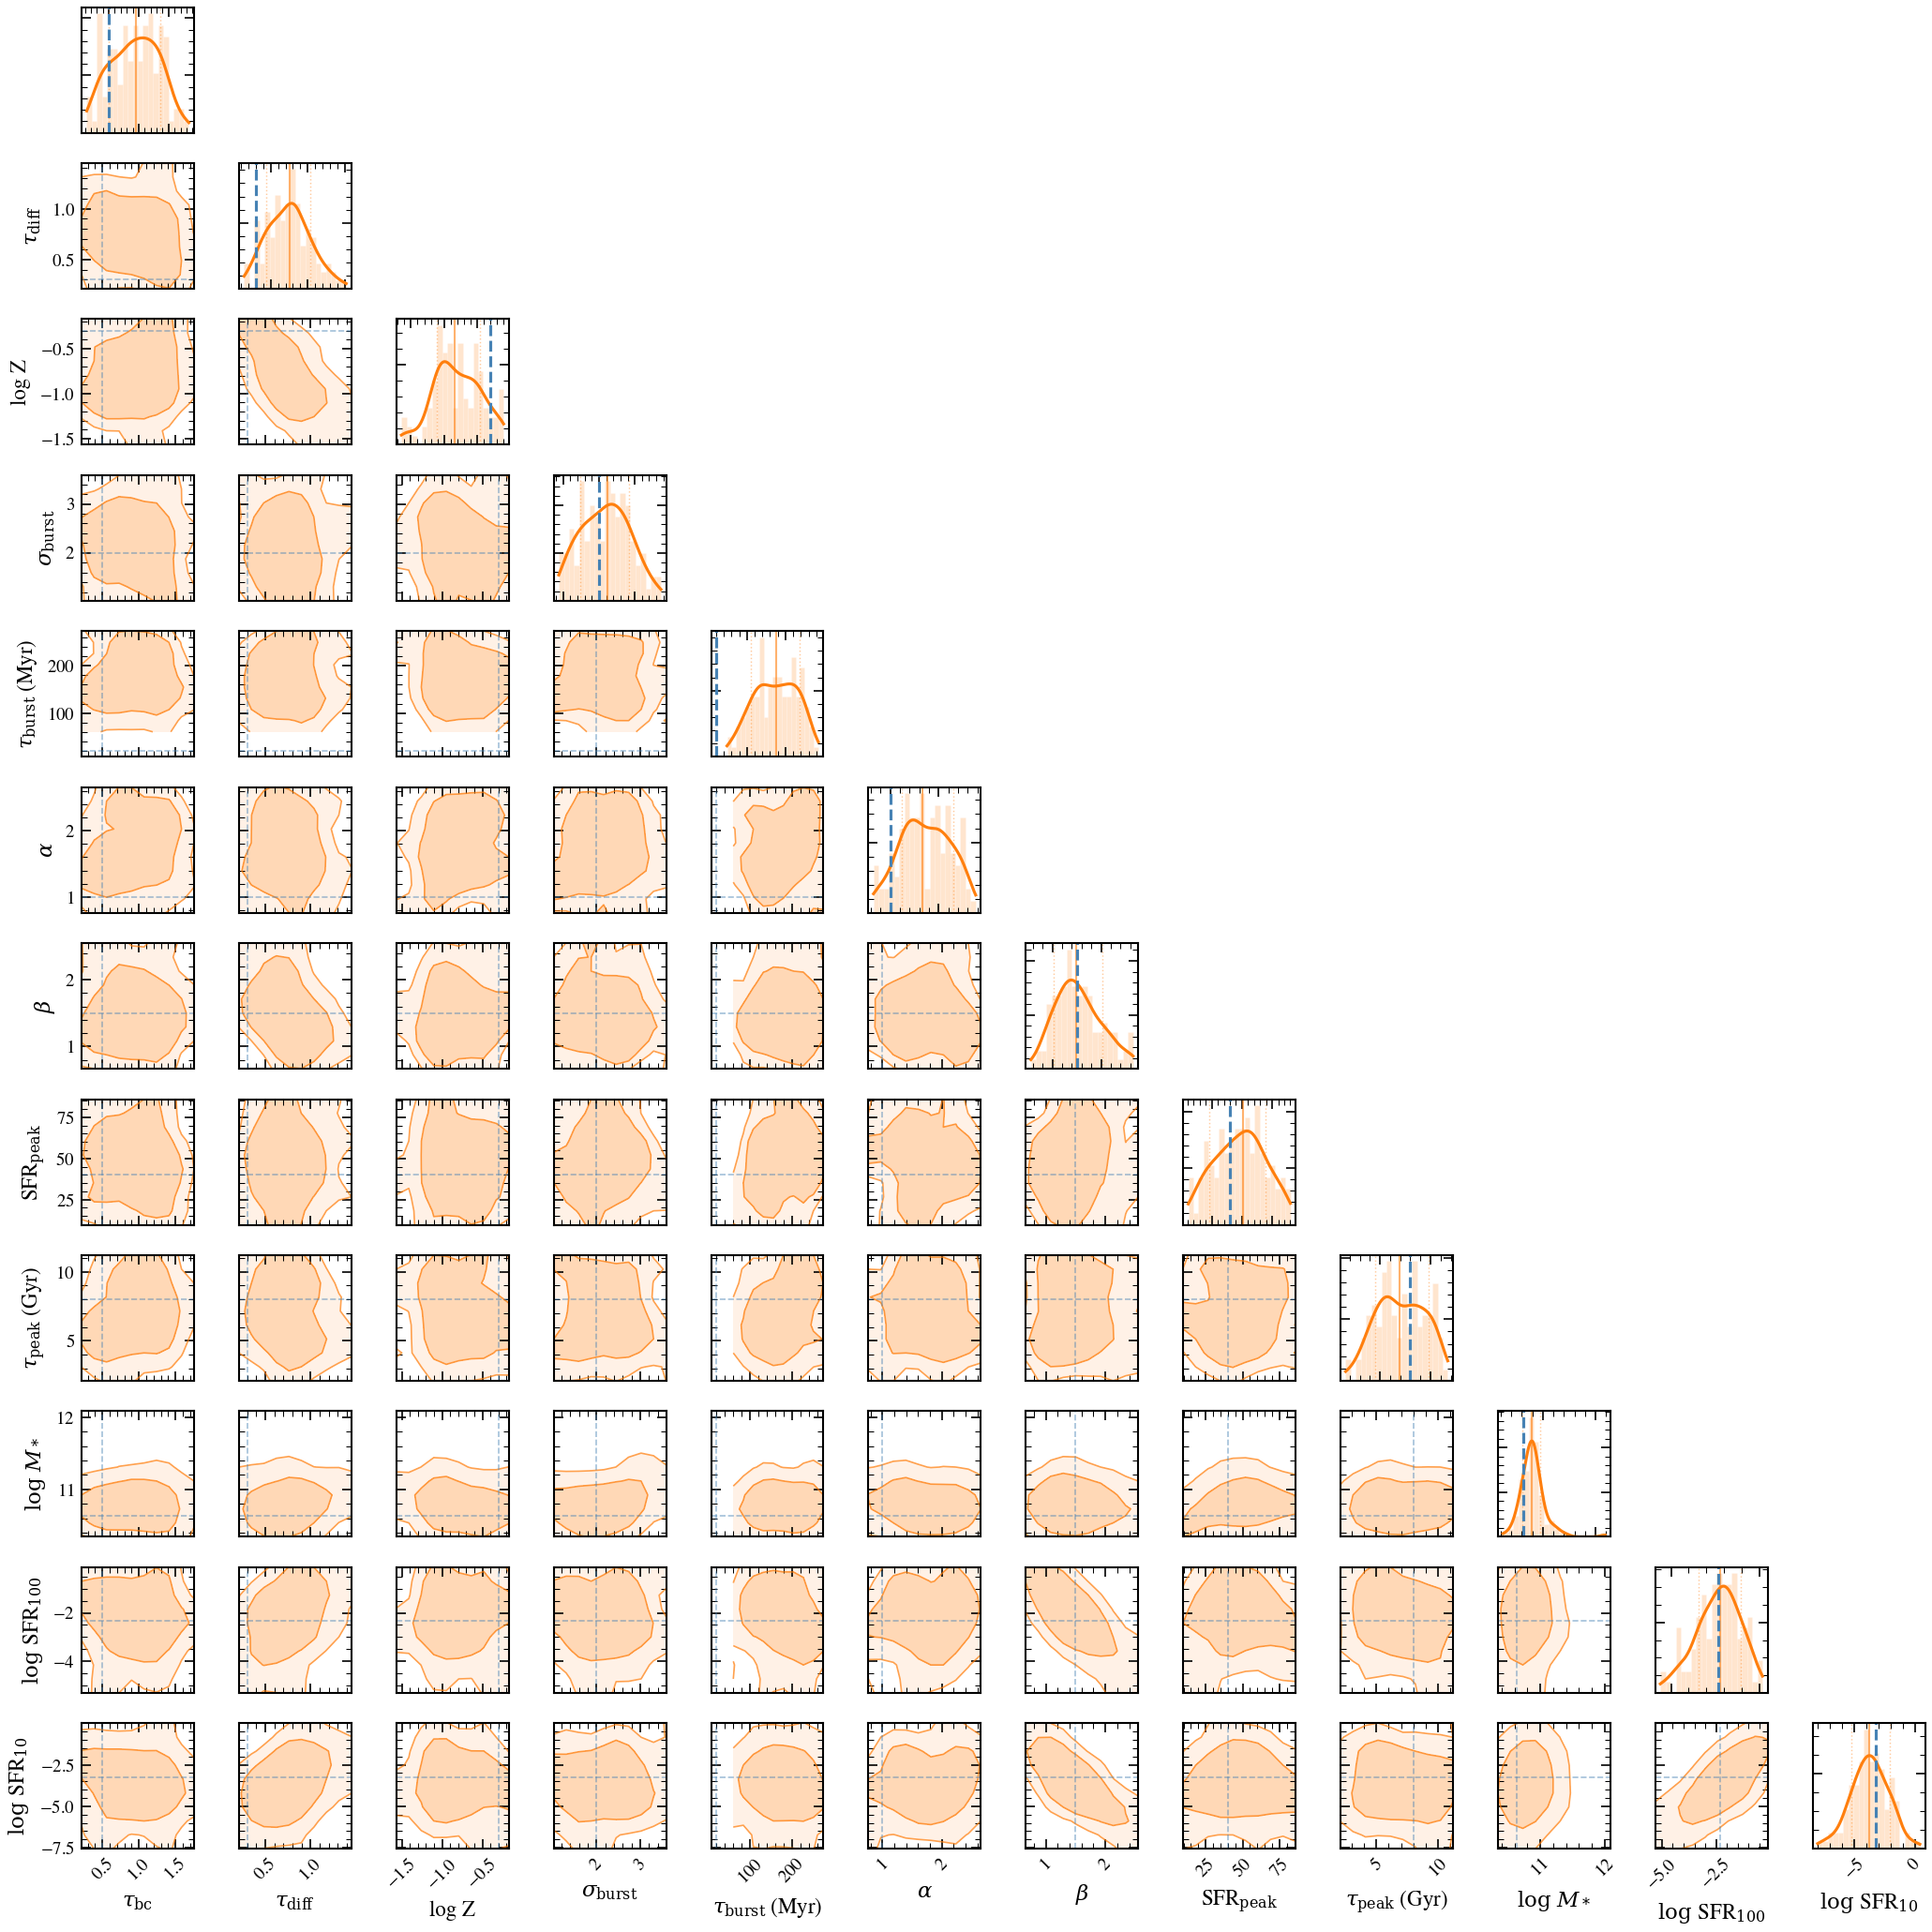

In [9]:
fig = plot_corner_comparison(
    [rt_s, geovi_s],
    ["Ray Tracing", "geoVI"],
    colors=[COLORS["rt"], COLORS["geovi"]],
    truths=true_s,
)
if fig is not None:
    savefig(fig, "corner_rt_vs_geovi")
plt.show()

### Timing comparison

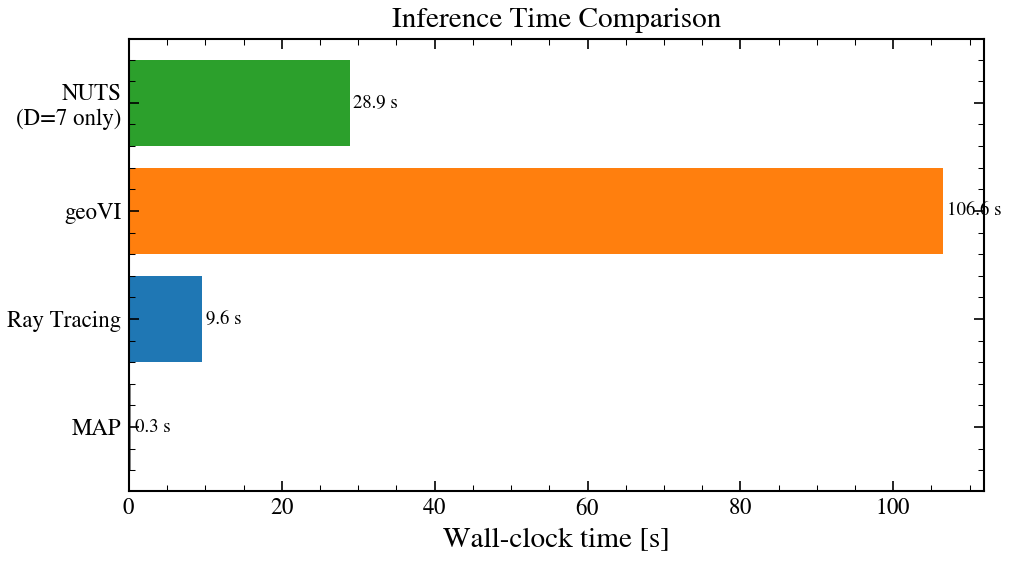

In [10]:
timings = {"MAP": map_s.wall_time_s if hasattr(map_s, 'wall_time_s') else 0,
           "Ray Tracing": t_rt, "geoVI": t_geovi, "NUTS\n(D=7 only)": t_nuts}
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(list(timings.keys()), list(timings.values()),
               color=[COLORS["map"], COLORS["rt"], COLORS["geovi"], COLORS["nuts"]])
ax.set_xlabel("Wall-clock time [s]")
ax.set_title("Inference Time Comparison")
for bar, val in zip(bars, timings.values()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f} s", va="center", fontsize=9)
fig.tight_layout(); savefig(fig, "timing_comparison"); plt.show()

## Practical Decision Tree

```
Is D < 20?
├── Yes → NUTS (gold standard, exact)
└── No → Is D < 300?
    ├── Yes → Ray Tracing (exact, noise-tolerant)
    └── No → Is D < 10⁴?
        ├── Yes → geoVI (approximate, scalable)
        └── No → MGVI (linear approximation, hierarchical regime)
```

**Always start with MAP for initialisation.**

**Next:** [T04 — Fitting](T04_fitting.ipynb) puts these methods to
work on photometric and spectroscopic data.